In [1]:
import dotenv
%load_ext dotenv
%dotenv

In [1]:
import dotenv
%load_ext dotenv
%dotenv

import os
import platform
import json
import random
import time

import jax
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from absl import app, flags
from ml_collections import config_flags

from agents import agents
from envs.env_utils import make_env_and_datasets
from utils.datasets import Dataset, ReplayBuffer
from utils.evaluation import evaluate, flatten, supply_rng
from utils.flax_utils import restore_agent, save_agent

import jax
import numpy as np
import matplotlib.pyplot as plt

def supply_rng(f, rng=jax.random.PRNGKey(0)):
    """Helper function to split the random number generator key before each call to the function."""

    def wrapped(*args, **kwargs):
        nonlocal rng
        rng, key = jax.random.split(rng)
        return f(*args, seed=key, **kwargs)

    return wrapped

# Configuration
env_name = "antmaze-large-navigate-singletask-task2-v0"
seed = 0
buffer_size = 2000000
eval_episodes = 10

# Agent paths and epochs
fql_agent_path = "/mnt/nas/jaehyeok/fql/exp/fql/Debug/fql_antmaze-large-navigate-singletask-task2-v0_sd000_20250827_170146"
ifql_agent_path = "/mnt/nas/jaehyeok/fql/exp/fql/Debug/ifql_antmaze-large-navigate-singletask-task2-v0_sd000_20250901_163207_utd-ratio1"
rebrac_agent_path = "/mnt/nas/jaehyeok/fql/exp/fql/Debug/rebrac_antmaze-large-navigate-singletask-task2-v0_sd000_20250902_003455_utd-ratio1"
fql_agent_epoch = 1000000
ifql_agent_epoch = 1000000
rebrac_agent_epoch = 1000000

# Make environment and datasets
env, eval_env, train_dataset, val_dataset = make_env_and_datasets(env_name, frame_stack=None)
train_dataset = Dataset.create(**train_dataset)
train_dataset = ReplayBuffer.create_from_initial_dataset(
    dict(train_dataset), size=max(buffer_size, train_dataset.size + 1)
)

# Initialize random seeds
random.seed(seed)
np.random.seed(seed)
example_batch = train_dataset.sample(1)

# Load FQL agent configuration and create agent
from agents.fql import get_config as get_fql_config
fql_config = get_fql_config()

fql_agent_class = agents[fql_config['agent_name']]
fql_agent = fql_agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    fql_config,
)

from agents.ifql import get_config as get_ifql_config
ifql_config = get_ifql_config()
ifql_agent_class = agents[ifql_config['agent_name']]
ifql_agent = ifql_agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    ifql_config,
)

# Restore trained models
if fql_agent_path and fql_agent_epoch:
    fql_agent = restore_agent(fql_agent, fql_agent_path, fql_agent_epoch)
    print(f"FQL agent restored from {fql_agent_path} at epoch {fql_agent_epoch}")

if ifql_agent_path and ifql_agent_epoch:
    ifql_agent = restore_agent(ifql_agent, ifql_agent_path, ifql_agent_epoch)
    print(f"IFQL agent restored from {ifql_agent_path} at epoch {ifql_agent_epoch}")

print("Models loaded successfully!")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:14: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:14: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


Restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fql_antmaze-large-navigate-singletask-task2-v0_sd000_20250827_170146/params_1000000.pkl
FQL agent restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fql_antmaze-large-navigate-singletask-task2-v0_sd000_20250827_170146 at epoch 1000000
Restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/ifql_antmaze-large-navigate-singletask-task2-v0_sd000_20250901_163207_utd-ratio1/params_1000000.pkl
IFQL agent restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/ifql_antmaze-large-navigate-singletask-task2-v0_sd000_20250901_163207_utd-ratio1 at epoch 1000000
Models loaded successfully!


In [2]:
# Generate trajectories for both agents
print("Generating trajectories for FQL agent...")
fql_eval_info, fql_trajs, fql_renders = evaluate(
    agent=fql_agent,
    env=eval_env,
    config=fql_config,
    num_eval_episodes=eval_episodes,
    num_video_episodes=0,  # Skip video rendering for now
    render_always=False,
)

print("Generating trajectories for IFQL agent...")
ifql_eval_info, ifql_trajs, ifql_renders = evaluate(
    agent=ifql_agent,
    env=eval_env,
    config=ifql_config,
    num_eval_episodes=eval_episodes,
    num_video_episodes=0,  # Skip video rendering for now
    render_always=False,
)

print(f"FQL evaluation results: {fql_eval_info}")
print(f"IFQL evaluation results: {ifql_eval_info}")
print(f"Generated {len(fql_trajs)} FQL trajectories and {len(ifql_trajs)} IFQL trajectories")


Generating trajectories for FQL agent...


100%|██████████| 10/10 [00:15<00:00,  1.53s/it]


Generating trajectories for IFQL agent...


  0%|          | 0/10 [00:00<?, ?it/s]2025-09-02 15:43:34.684012: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-09-02 15:43:34.684069: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
100%|██████████| 10/10 [00:26<00:00,  2.62s/it]

FQL evaluation results: defaultdict(<class 'list'>, {'xy': 14.567657760486743, 'prev_qpos': 2.023514954013263, 'prev_qvel': 0.0842556061629657, 'qpos': 2.023478797134264, 'qvel': -0.038032876685632044, 'success': 0.7, 'total.timesteps': 4124.8, 'episode.final_reward': -0.3, 'episode.return': -806.1, 'episode.length': 806.8, 'episode.duration': 1.5324353456497193})
IFQL evaluation results: defaultdict(<class 'list'>, {'xy': 14.395288344108167, 'prev_qpos': 1.959204547402214, 'prev_qvel': 0.005710349403377852, 'qpos': 1.9615808761278857, 'qvel': 0.061639453611362804, 'success': 0.1, 'total.timesteps': 13541.0, 'episode.final_reward': -0.9, 'episode.return': -986.4, 'episode.length': 986.5, 'episode.duration': 2.623262071609497})
Generated 10 FQL trajectories and 10 IFQL trajectories


In [4]:
fql_actor_fn = supply_rng(fql_agent.sample_actions, rng=jax.random.PRNGKey(np.random.randint(0, 2**32)))
ifql_actor_fn = supply_rng(ifql_agent.sample_actions, rng=jax.random.PRNGKey(np.random.randint(0, 2**32)))
eval_temperature = 0


# Generate ifql actor output along the fql trajectory
for i in range(eval_episodes):
    ifql_actions_along_fql_traj = []
    ifql_traj_ifql_q_values = []
    fql_traj_ifql_q_values = []

    fql_observations = fql_trajs[i]['observation']
    fql_next_observations = fql_trajs[i]['next_observation']
    fql_done = fql_trajs[i]['done']
    ifql_observations = ifql_trajs[i]['observation']

    fql_actions = fql_trajs[i]['action']
    ifql_actions = ifql_trajs[i]['action']

    final_observation = None

    for fql_observation, fql_action, fql_done in tqdm(zip(fql_observations, fql_actions, fql_done)):
        ifql_action = ifql_actor_fn(observations=fql_observation, temperature=eval_temperature)
        ifql_actions_along_fql_traj.append(ifql_action)

        if fql_done:
            final_observation = fql_observation
            break
    
    # Batched computation of Q values for faster computation
    ifql_actions_batch = np.array(ifql_actions_along_fql_traj)
    fql_observations_batch = np.array(fql_observations[:len(ifql_actions_along_fql_traj)])
    fql_actions_batch = np.array(fql_actions[:len(ifql_actions_along_fql_traj)])
    fql_next_observations_batch = np.array(fql_next_observations[:len(ifql_actions_along_fql_traj)])
    
    # Compute Q values with IFQL critic in batches of 256
    batch_size = 256
    
    # First: FQL observations with IFQL actions
    ifql_traj_ifql_q_values_batches = []
    for start_idx in tqdm(range(0, len(fql_observations_batch), batch_size)):
        end_idx = min(start_idx + batch_size, len(fql_observations_batch))
        obs_batch = fql_observations_batch[start_idx:end_idx]
        actions_batch = ifql_actions_batch[start_idx:end_idx]
        q_values_batch = ifql_agent.network.select('critic')(obs_batch, actions=actions_batch)
        ifql_traj_ifql_q_values_batches.append(q_values_batch)
    ifql_traj_ifql_q_values = np.concatenate(ifql_traj_ifql_q_values_batches, axis=1)
    
    # Second: FQL observations with FQL actions
    fql_traj_ifql_q_values_batches = []
    for start_idx in tqdm(range(0, len(fql_observations_batch), batch_size)):
        end_idx = min(start_idx + batch_size, len(fql_observations_batch))
        obs_batch = fql_observations_batch[start_idx:end_idx]
        actions_batch = fql_actions_batch[start_idx:end_idx]
        q_values_batch = ifql_agent.network.select('critic')(obs_batch, actions=actions_batch)
        fql_traj_ifql_q_values_batches.append(q_values_batch)
    fql_traj_ifql_q_values = np.concatenate(fql_traj_ifql_q_values_batches, axis=1)
    break

    

610it [00:00, 1542.61it/s]
100%|██████████| 3/3 [00:00<00:00, 15.53it/s]


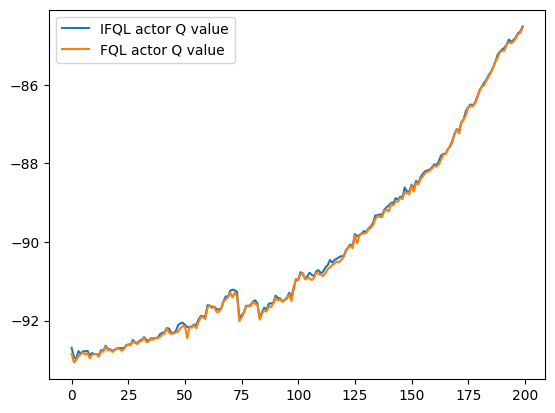

In [41]:
# IFQL evaluated Q value different between IFQL and FQL actor
ifql_traj_ifql_q_values = np.array(ifql_traj_ifql_q_values)
ifql_traj_ifql_q_values_min = ifql_traj_ifql_q_values.min(axis=0)[:200]
fql_traj_ifql_q_values = np.array(fql_traj_ifql_q_values)
fql_traj_ifql_q_values_min = fql_traj_ifql_q_values.min(axis=0)[:200]

eval_time_steps = np.arange(0, ifql_traj_ifql_q_values.shape[-1])[:200]

plt.plot(ifql_traj_ifql_q_values_min, label='IFQL actor Q value')
plt.plot(fql_traj_ifql_q_values_min, label='FQL actor Q value')
plt.legend()
plt.show()

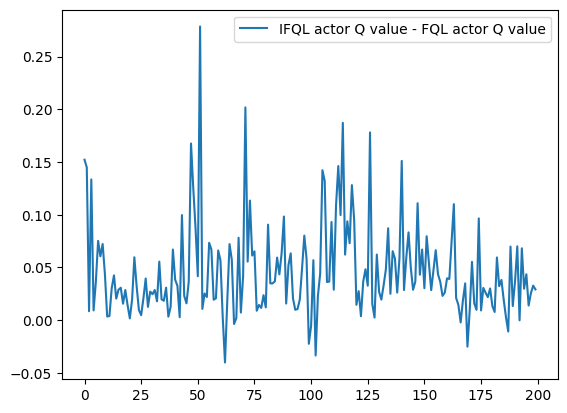

In [43]:
plt.plot(eval_time_steps,
    ifql_traj_ifql_q_values_min - fql_traj_ifql_q_values_min, 
         label='IFQL actor Q value - FQL actor Q value')
plt.legend()

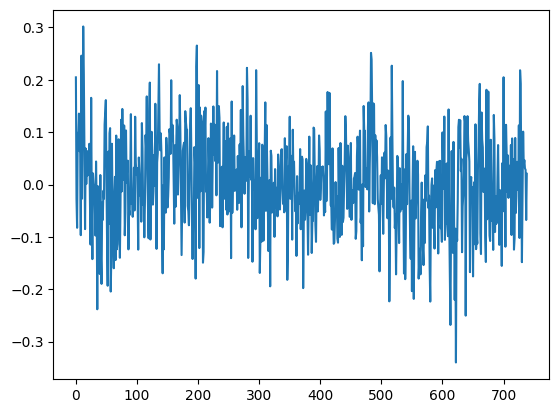

In [50]:
action_diff = np.array(ifql_actions_along_fql_traj) - np.array(fql_actions)
mean_action_diff = action_diff.mean(axis=-1)

plt.plot(eval_time_steps, mean_action_diff)
plt.show()

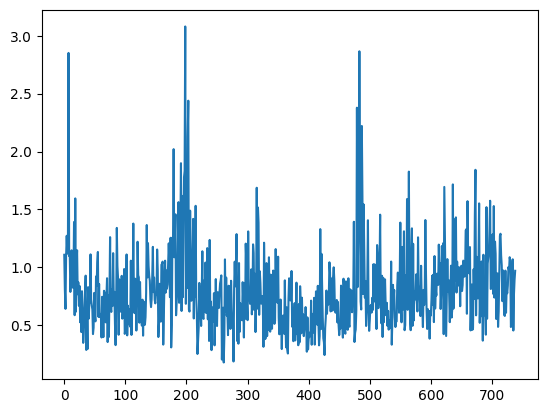

In [53]:
action_diff_norm = np.linalg.norm(np.array(ifql_actions_along_fql_traj) - np.array(fql_actions), axis=-1)

plt.plot(eval_time_steps, action_diff_norm)
plt.show()

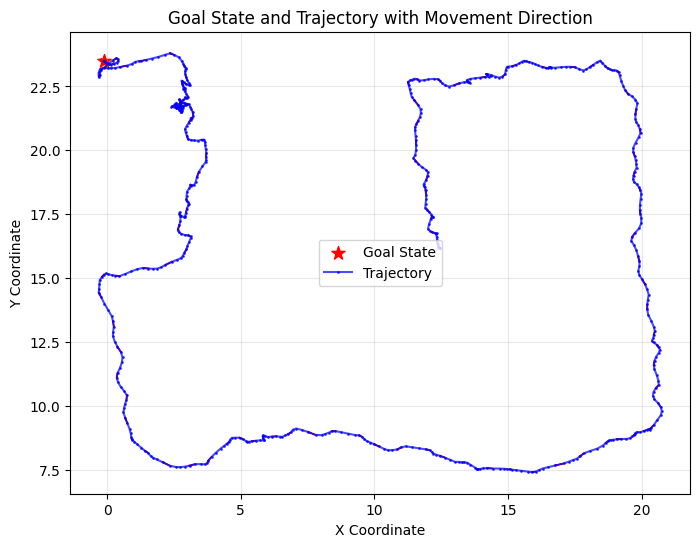

In [7]:
target_timesteps = np.arange(450, 500)
target_timesteps = np.arange(0, fql_observations_batch.shape[0])
goal_state = final_observation[:2]
curr_pos = fql_observations_batch[target_timesteps,:2]
next_pos = fql_next_observations_batch[target_timesteps,:2]
pos_diff = next_pos - curr_pos  

plt.figure(figsize=(8, 6))
plt.scatter(goal_state[0], goal_state[1], color='red', s=100, marker='*', label='Goal State')
plt.plot(curr_pos[:,0], curr_pos[:,1], color='blue', marker='o', markersize=1, alpha=0.7, label='Trajectory')
for i in range(len(curr_pos)):
    if i % 5 == 0:  # Show arrows every 5 steps to avoid clutter
        plt.arrow(curr_pos[i,0], curr_pos[i,1], pos_diff[i,0], pos_diff[i,1], 
                  head_width=0.05, head_length=0.02, fc='red', ec='red', alpha=0.9)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.title('Goal State and Trajectory with Movement Direction')
plt.grid(True, alpha=0.3)
plt.show()


In [6]:
qpos_dim = 15
qvel_dim = 14
eval_env.reset()

rewards = []
for i in range(fql_observations_batch.shape[0]):
    obs = fql_observations_batch[i]
    qpos = obs[:qpos_dim]
    qvel = obs[qpos_dim:qpos_dim+qvel_dim]

    eval_env.set_state(qpos, qvel)
    
    fql_action = fql_actions_batch[i]
    ob, reward, terminated, truncated, info = eval_env.step(fql_action)
    if terminated:
        print(i)
    rewards.append(reward)

np.array(rewards).mean()
    

/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.set_state to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.set_state` for environment variables or `env.get_wrapper_attr('set_state')` that will search the reminding wrappers.
  logger.warn(


-1.0

In [8]:
qpos_dim = 15
qvel_dim = 14
eval_env.reset()

rewards = []
ifql_next_actions_along_fql_traj = []
for i in range(fql_observations_batch.shape[0]):
    obs = fql_observations_batch[i]
    qpos = obs[:qpos_dim]
    qvel = obs[qpos_dim:qpos_dim+qvel_dim]

    eval_env.set_state(qpos, qvel)
    
    ifql_action = ifql_actions_along_fql_traj[i]
    ob, reward, terminated, truncated, info = eval_env.step(ifql_action)
    ifql_next_actions_along_fql_traj.append(ob)
    if terminated:
        print(i)
    rewards.append(reward)

ifql_next_actions_along_fql_traj = np.array(ifql_next_actions_along_fql_traj)
np.array(rewards).mean()
    

-1.0

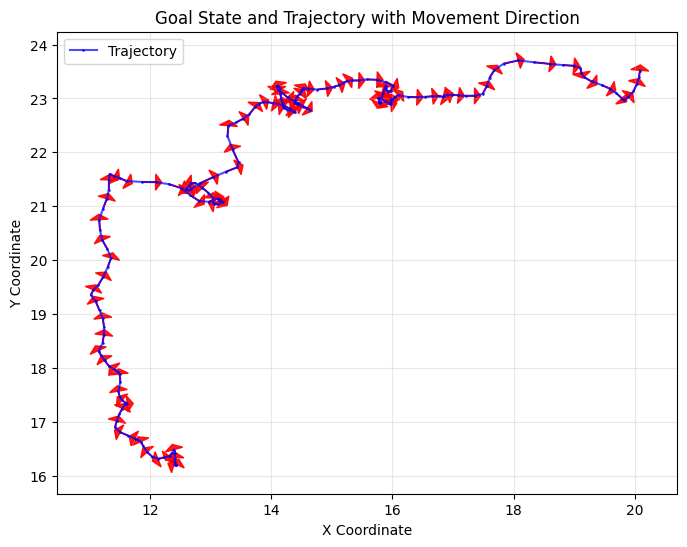

In [135]:
target_timesteps = np.arange(0, fql_observations_batch.shape[0])
target_timesteps = np.arange(0, 200)

goal_state = final_observation[:2]
curr_pos = fql_observations_batch[target_timesteps,:2]
next_pos = ifql_next_actions_along_fql_traj[target_timesteps,:2]
pos_diff = next_pos - curr_pos  

plt.figure(figsize=(8, 6))
# plt.scatter(goal_state[0], goal_state[1], color='red', s=100, marker='*', label='Goal State')
plt.plot(curr_pos[:,0], curr_pos[:,1], color='blue', marker='o', markersize=1, alpha=0.7, label='Trajectory')
for i in range(len(curr_pos)):
    if i % 2 == 0:  # Show arrows every 5 steps to avoid clutter
        plt.arrow(curr_pos[i,0], curr_pos[i,1], pos_diff[i,0], pos_diff[i,1], 
                  head_width=0.3, head_length=0.1, fc='red', ec='red', alpha=0.9)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.title('Goal State and Trajectory with Movement Direction')
plt.grid(True, alpha=0.3)
plt.show()


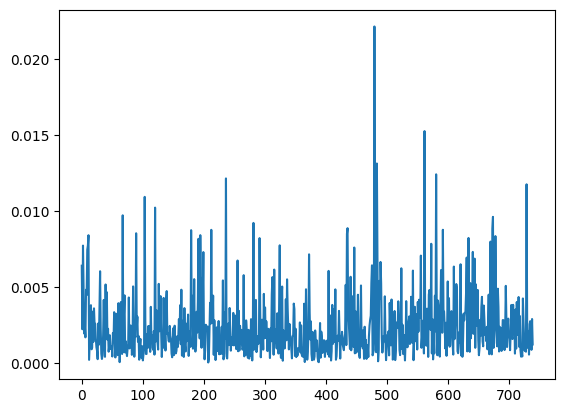

In [130]:
# next observation MAE
mae = np.mean(np.abs(ifql_next_actions_along_fql_traj[:,:2] - fql_next_observations_batch[:,:2]), axis=-1)
plt.plot(mae)

In [20]:
import jax.numpy as jnp

ifql_actor_fn = supply_rng(ifql_agent.sample_actions, rng=jax.random.PRNGKey(np.random.randint(0, 2**32)))
eval_temperature = 0
qpos_dim = 15
qvel_dim = 14

rewards = []
ob, info = eval_env.reset()

success = 0
for _ in range(1):
    ob, info = eval_env.reset()
    for j, _ in tqdm(enumerate(range(1000))):
        _, full_candidates = ifql_actor_fn(observations=ob, temperature=eval_temperature)
        full_candidates = np.clip(np.array(full_candidates), -1, 1)
        # Plot the direction of full_candidates (action samples)
        # if len(full_candidates.shape) > 1 and full_candidates.shape[0] > 1:
        #     # Extract position components (assuming first 2 dimensions are x, y positions)

        #     # Save the current observation, compute the next direction by iteratively setting the env state, then reset to the saved observation
        #     saved_observation = ob
        #     candidate_positions = []
        #     for candidate_action in full_candidates:
        #         eval_env.set_state(saved_observation[:qpos_dim], saved_observation[qpos_dim:qpos_dim+qvel_dim])
        #         cand_ob, _, _, _, _ = eval_env.step(candidate_action)
        #         candidate_positions.append(cand_ob[:2])
        #     eval_env.set_state(saved_observation[:qpos_dim], saved_observation[qpos_dim:qpos_dim+qvel_dim])
        #     candidate_positions = np.array(candidate_positions)

        #     current_pos = ob[:2]  # Current position
            
        #     # Calculate direction vectors from current position
        #     directions = candidate_positions - current_pos
            
        #     # Clear previous plot and create new one for each step
        #     plt.clf()
        #     plt.figure(figsize=(8, 6))
        #     plt.scatter(current_pos[0], current_pos[1], color='blue', s=100, marker='o', label='Current Position')
            
        #     # Plot direction arrows for all candidate actions
        #     for i, direction in enumerate(directions):
        #         alpha = 0.7 if i < len(directions) - 1 else 1.0  # Highlight selected action
        #         color = 'red' if i == np.argmax([np.linalg.norm(d) for d in directions]) else 'gray'
        #         # Calculate adaptive arrow size based on direction magnitude
        #         direction_magnitude = np.linalg.norm(direction)
        #         head_width = max(0.01, min(0.1, direction_magnitude * 0.1))
        #         head_length = max(0.005, min(0.05, direction_magnitude * 0.05))
                
        #         plt.arrow(current_pos[0], current_pos[1], direction[0], direction[1],
        #                  head_width=head_width, head_length=head_length, fc=color, ec=color, alpha=alpha)
            
        #     plt.xlabel('X Direction')
        #     plt.ylabel('Y Direction')
        #     plt.title(f'Action Candidate Directions (Step {_})')
        #     plt.legend()
        #     plt.grid(True, alpha=0.3)
        #     plt.axis('equal')
        #     plt.show()
        #     input()
        n_orig_observations = jnp.repeat(jnp.expand_dims(ob, 0), full_candidates.shape[0], axis=0)
        q = fql_agent.network.select('critic')(n_orig_observations, actions=full_candidates).min(axis=0)
        selected_action = full_candidates[jnp.argmax(q)]
        ob, reward, terminated, truncated, info = eval_env.step(selected_action)
        if j % 10 == 0:
            print(ob[:2])
        if terminated:
            break
        rewards.append(reward)
    if info['success']:
        success += 1
    

4it [00:00, 16.13it/s]

[11.36995011 15.33737793]


14it [00:00, 16.68it/s]

[11.64846026 16.12212707]


24it [00:01, 16.49it/s]

...

294it [00:17, 17.24it/s]

[19.17318775 16.39935028]


303it [00:18, 16.80it/s]

[19.22112031 15.31884628]


KeyboardInterrupt: 

In [26]:
eval_timestep = 1000

qpos_dim = 15
qvel_dim = 14

num_trials = 100

ifql_avg_rewards = []
ifql_avg_terminated_timesteps = []
ifql_avg_terminated_timesteps_on_success = []
fql_avg_rewards = []
fql_avg_terminated_timesteps = []
fql_avg_terminated_timesteps_on_success = []

ifql_terminated_timesteps = []
fql_terminated_timesteps = []
ifql_success = []
fql_success = []

exps = range(0, 1000, 100)

for start_timestep in exps:
    eval_timestep = 1000 - start_timestep

    if start_timestep > fql_observations_batch.shape[0]:
        break
    avg_rewards = []
    terminated_timesteps = []
    success = 0
    for _ in tqdm(range(num_trials)):
        eval_env.reset()
        ob = fql_observations_batch[start_timestep]
        init_qpos = ob[:qpos_dim]
        init_qvel = ob[qpos_dim:qpos_dim+qvel_dim]
        eval_env.set_state(init_qpos, init_qvel)
        rewards = []

        
        for i in range(eval_timestep):
            ifql_action = ifql_actor_fn(observations=ob, temperature=eval_temperature)
            ob, reward, terminated, truncated, info = eval_env.step(ifql_action)
            rewards.append(reward)
            if terminated:
                terminated_timesteps.append(i)
                if info['success']:
                    success += 1
                break
        avg_rewards.append(np.array(rewards).mean())

    ifql_success.append(success)
    ifql_avg_rewards.append(np.array(avg_rewards).mean())
    ifql_avg_terminated_timesteps.append(np.array(terminated_timesteps).mean())

    avg_rewards = []
    terminated_timesteps = []
    success = 0
    for _ in range(num_trials):
        eval_env.reset()
        ob = fql_observations_batch[start_timestep]
        init_qpos = ob[:qpos_dim]
        init_qvel = ob[qpos_dim:qpos_dim+qvel_dim]
        eval_env.set_state(init_qpos, init_qvel)
        rewards = []

        
        for i in range(eval_timestep):
            fql_action = fql_actor_fn(observations=ob, temperature=eval_temperature)
            ob, reward, terminated, truncated, info = eval_env.step(fql_action)
            rewards.append(reward)
            if terminated:
                terminated_timesteps.append(i)
                if info['success']:
                    success += 1
                break
        avg_rewards.append(np.array(rewards).mean())

    fql_success.append(success)
    fql_avg_rewards.append(np.array(avg_rewards).mean())
    fql_avg_terminated_timesteps.append(np.array(terminated_timesteps).mean())

100%|██████████| 100/100 [00:03<00:00, 27.54it/s]


/tmp/ipykernel_1378661/4064129152.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


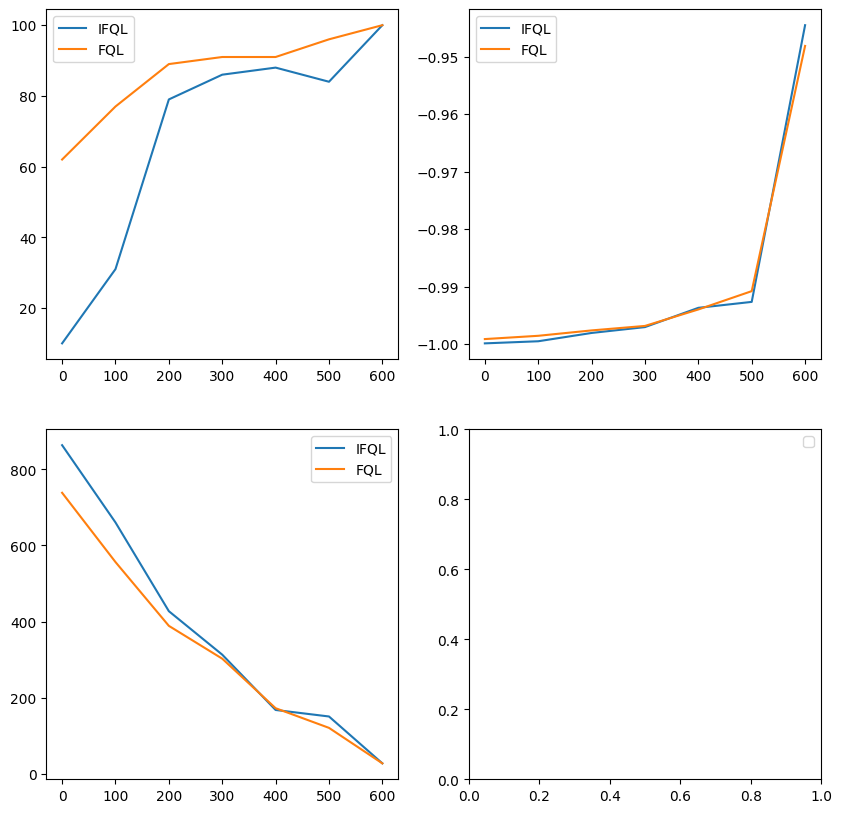

In [30]:
# plot the results (subfigures)
plot_timesteps = exps[:len(ifql_success)]

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.plot(plot_timesteps, ifql_success, label="IFQL")
plt.plot(plot_timesteps, fql_success, label="FQL")
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(plot_timesteps, ifql_avg_rewards, label="IFQL")
plt.plot(plot_timesteps, fql_avg_rewards, label="FQL")
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(plot_timesteps, ifql_avg_terminated_timesteps, label="IFQL")
plt.plot(plot_timesteps, fql_avg_terminated_timesteps, label="FQL")
plt.legend()
plt.show()

In [32]:
ifql_success

[10, 31, 79, 86, 88, 84, 100]

In [33]:
fql_success

[62, 77, 89, 91, 91, 96, 100]